In [21]:
import h5py
import pygmt
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [22]:
def to_xarray(data, x, y, key='z'):
    """Converts a 2D numpy array to an xarray.DataArray"""
    return xr.DataArray(data.T, coords=[y, x], dims=[ "lat", "lon"], name=key)

In [23]:
with h5py.File('OUTPUT_FILES/final_model.h5') as f:
    vs = f['vs'][:]
    theta = f['theta'][:]
    g0 = f['g0'][:]
    gc = f['gc'][:]
    gs = f['gs'][:]
    lon = f['x'][:]
    lat = f['y'][:]
    depths = f['z'][:]
lonmin, lonmax = np.min(lon), np.max(lon)
latmin, latmax = np.min(lat), np.max(lat)
with h5py.File('OUTPUT_FILES/initial_model.h5') as f:
    init = f['vs'][:]
dv = (vs - init) / init * 100

with h5py.File('OUTPUT_FILES/target_model.h5') as f:
    tvs = f['vs'][:]
    tgc = f['gc'][:]
    tgs = f['gs'][:]
    tg0 = f['g0'][:]
    ttheta = f['theta'][:]
tdv = (tvs - init) / init * 100

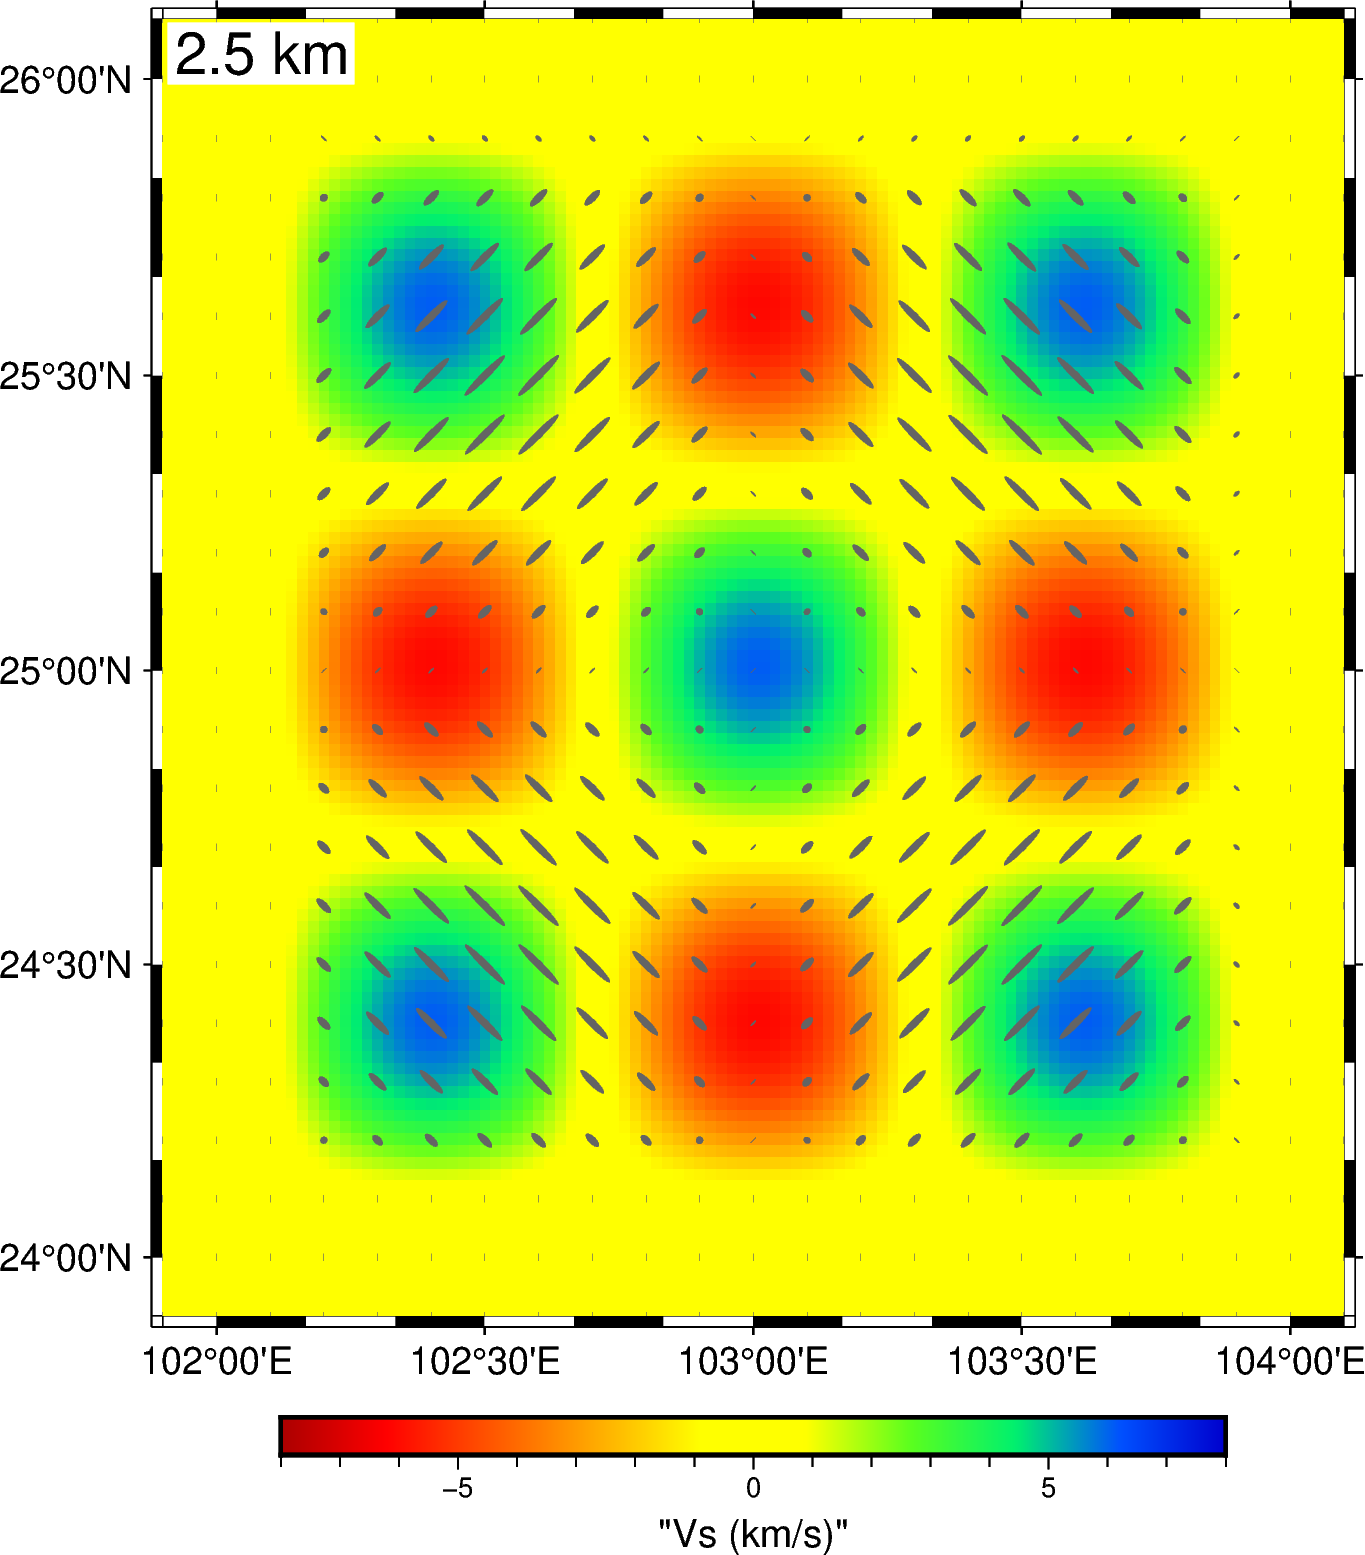

In [24]:
# Plot the true model
dep = 5
dn = 5
region = [lonmin, lonmax, latmin, latmax]
# grid_vs = pygmt.surface(data=data1[:, [0,1,3]], region=region, spacing='0.02/0.02')
grid_vs = to_xarray(tdv[:,:,int(dep)], lon, lat)
grid_g0 = to_xarray(tg0[:,:,int(dep)], lon, lat)
grid_g0_samp = to_xarray(tg0[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
grid_theta = to_xarray(ttheta[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
xyz_theta = pygmt.grd2xyz(grid_theta)
xyz_g0 = pygmt.grd2xyz(grid_g0_samp)
ani = pd.concat([xyz_theta['lon'], xyz_theta['lat'], xyz_theta['z'], xyz_g0['z']*8], axis=1)
# ani = pd.concat([xyz_gc['lon'], xyz_gc['lat'], theta, g0*8], axis=1)
ani['minax'] = np.ones_like(ani['lon'])*0.06
fig = pygmt.Figure()
fig.basemap(region=region, projection='M10c', frame=True)
pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], continuous=True)
fig.grdimage(grid_vs, cmap=True)
fig.plot(ani, style='e',  fill='100')
fig.text(text=f'{depths[dep]} km', x=region[0], y=region[3], font='14p', justify='TL', no_clip=True, offset='0.1c/-0.1c', fill='255')
fig.colorbar(frame='af+l"Vs (km/s)"')
fig.show()

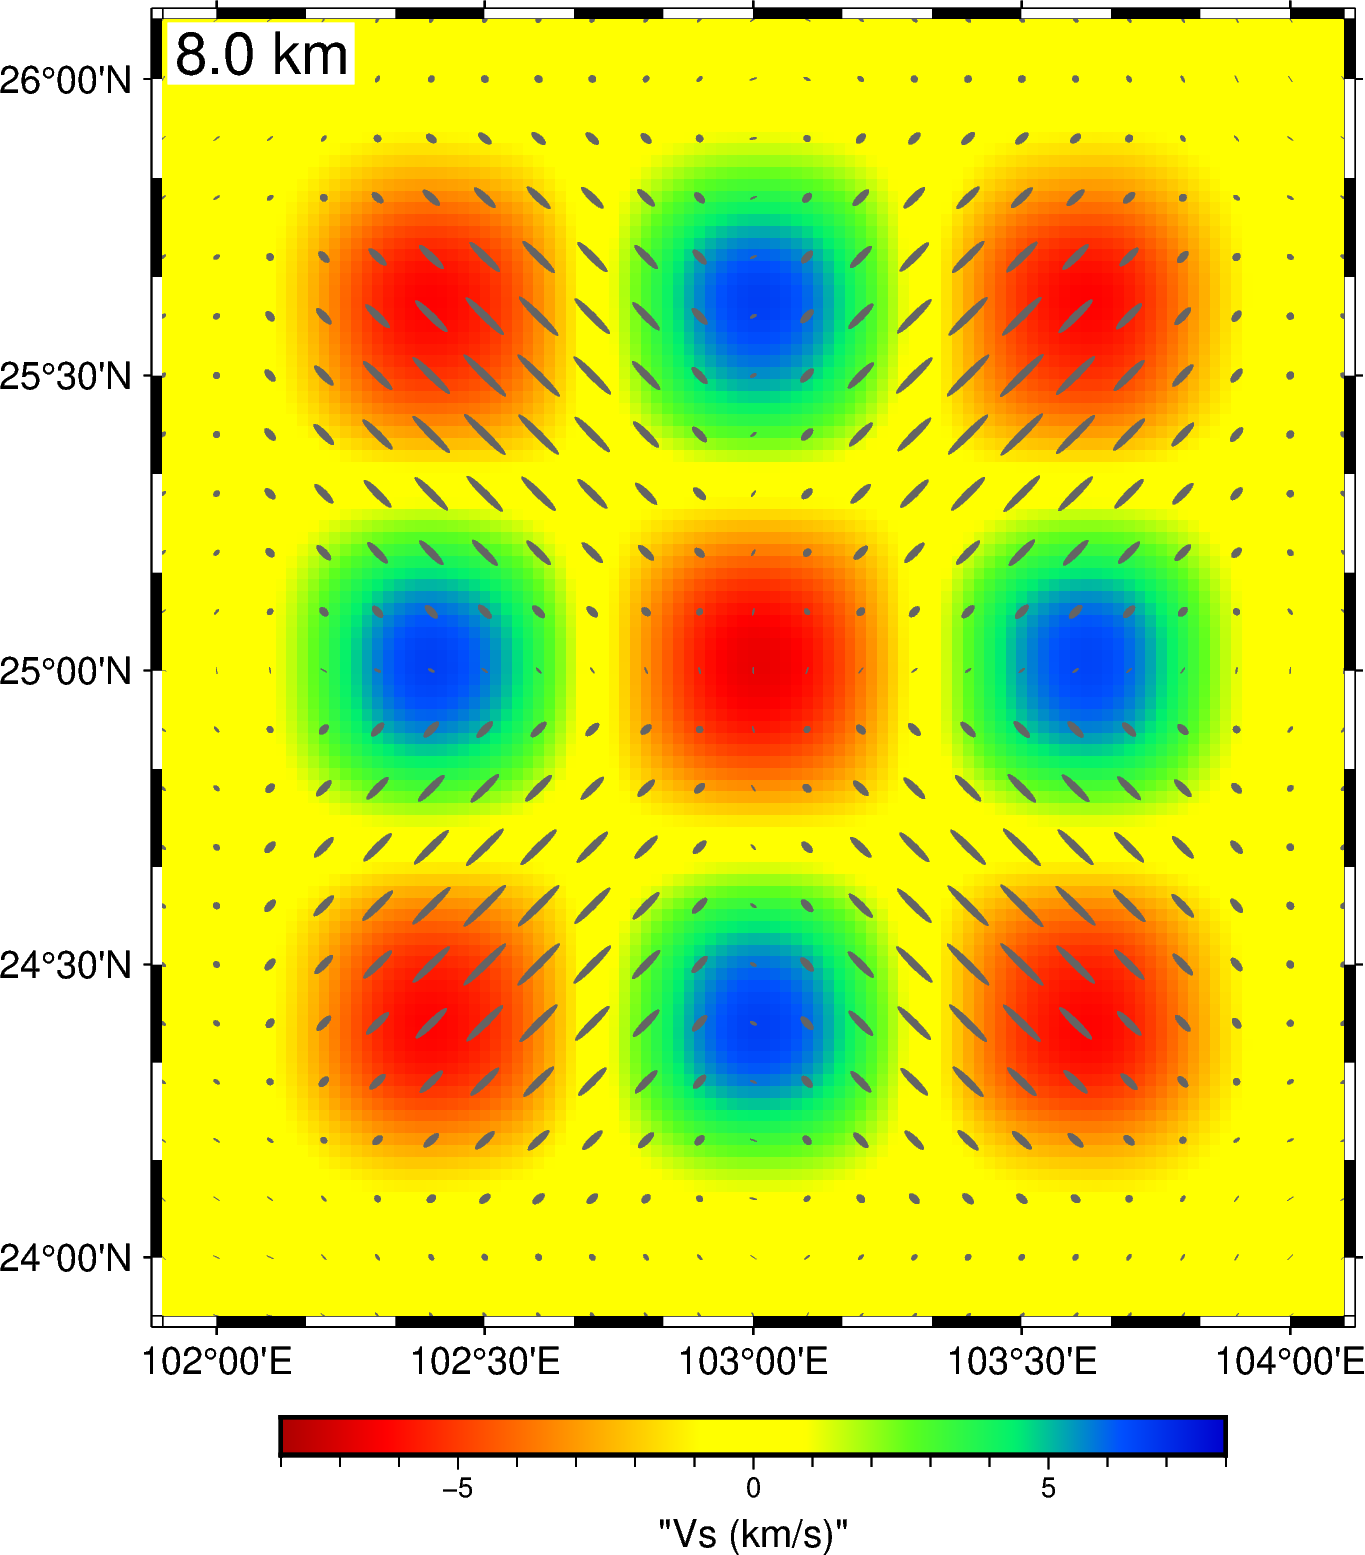

In [25]:
# Plot the inverted model
dep = 16
dn = 5
region = [lonmin, lonmax, latmin, latmax]
# grid_vs = pygmt.surface(data=data1[:, [0,1,3]], region=region, spacing='0.02/0.02')
grid_vs = to_xarray(dv[:,:,int(dep)], lon, lat)
grid_g0 = to_xarray(g0[:,:,int(dep)], lon, lat)
grid_g0_samp = to_xarray(g0[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
grid_theta = to_xarray(theta[::dn,::dn, int(dep)], lon[::dn], lat[::dn])
xyz_theta = pygmt.grd2xyz(grid_theta)
xyz_g0 = pygmt.grd2xyz(grid_g0_samp)
ani = pd.concat([xyz_theta['lon'], xyz_theta['lat'], xyz_theta['z'], xyz_g0['z']*8], axis=1)
# ani = pd.concat([xyz_gc['lon'], xyz_gc['lat'], theta, g0*8], axis=1)
ani['minax'] = np.ones_like(ani['lon'])*0.06
fig = pygmt.Figure()
fig.basemap(region=region, projection='M10c', frame=True)
pygmt.makecpt(cmap='seis', series=[-8, 8, 0.1], continuous=True)
fig.grdimage(grid_vs, cmap=True)
fig.plot(ani, style='e',  fill='100')
fig.text(text=f'{depths[dep]} km', x=region[0], y=region[3], font='14p', justify='TL', no_clip=True, offset='0.1c/-0.1c', fill='255')
fig.colorbar(frame='af+l"Vs (km/s)"')
fig.show()